<div style="background:linear-gradient(120deg,#00f5a0,#00d9f5,#b95cff); color:red; font-weight:800; padding:18px; border-radius:20px; text-align:center; font-size:60px;">
Real & Fake Face Detection  
</div>

<div style="background:linear-gradient(120deg,#00f5a0,#00d9f5,#b95cff); color:black; font-weight:800; padding:18px; border-radius:20px; text-align:center; font-size:60px;">
import libraries & modules
</div>

In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('dark_background')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from tensorflow.keras.utils import to_categorical
import os

In [3]:
encoder=OneHotEncoder()
encoder.fit([[0],[1]])

OneHotEncoder()

In [4]:
data=[]
paths=[]
result=[]
for r,d,f in os.walk(r"C:\Users\GCE PMNA\Downloads\archive (17)"):
    for file in f:
        if'.jpg' or '.jpeg' in file:
            paths.append(os.path.join(r,file))
for path in paths:
    img=Image.open(path)
    img=img.resize((128,128))
    img=np.array(img)
    if(img.shape==(128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[1]]).toarray())

In [5]:
paths=[]
for r,d,f in os.walk(r"C:\Users\GCE PMNA\Downloads\archive (17)"):
    for file in f:
        if '.jpg' in file or '.jpeg' in file:
            paths.append(os.path.join(r,file))
for path in paths:
    img=Image.open(path)
    img=img.resize((128,128))
    img=np.array(img)
    if(img.shape==(128,128,3)):
        data.append(np.array(img))
        result.append(encoder.transform([[0]]).toarray())

In [6]:
data=np.array(data)
data.shape

(4082, 128, 128, 3)

In [7]:
result = np.array(result)
result = result.reshape(4082, 2)

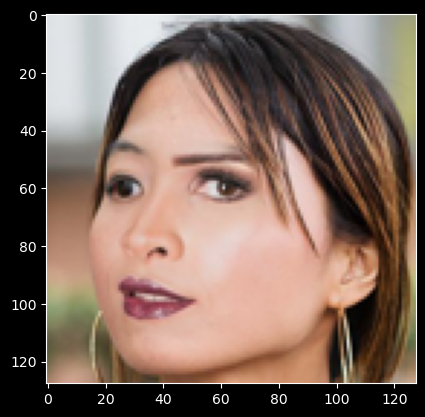

In [8]:
plt.imshow(data[45])

<div style="background:linear-gradient(120deg,#00f5a0,#00d9f5,#b95cff); color:black; font-weight:800; padding:18px; border-radius:20px; text-align:center; font-size:60px;">
Model Train  
</div>

In [9]:
x_train,x_test,y_train,y_test=train_test_split(data,result,test_size=0.2,shuffle=True,random_state=0)

<div style="background:linear-gradient(120deg,#00f5a0,#00d9f5,#b95cff); color:black; font-weight:800; padding:18px; border-radius:20px; text-align:center; font-size:60px;">
Build cnn model  
</div>

In [11]:
model = Sequential()

model.add(Conv2D(32, kernel_size=(2, 2), input_shape=(128, 128, 3), padding = 'Same'))
model.add(Conv2D(32, kernel_size=(2, 2),  activation ='relu', padding = 'Same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(0.25))

model.add(Conv2D(64, kernel_size = (2,2), activation ='relu', padding = 'Same'))
model.add(Conv2D(64, kernel_size = (2,2), activation ='relu', padding = 'Same'))
model.add(Dropout(0.45))

model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=(2,2)))
model.add(Dropout(0.25))

model.add(Flatten())

model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(2, activation='sigmoid'))

print(model.summary())

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 65536)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    33,554,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,585,602 (128.12 MB)

 Trainable params: 33,585,410 (128.12 MB)

 Non-trainable params: 192 (768.00 B)

None


loss function: calculate the diffrence between predicted output and the actual target 
optimizer : update te weight of a neural network (decreas loss function)


<div style="background:linear-gradient(120deg,#00f5a0,#00d9f5,#b95cff); color:black; font-weight:800; padding:18px; border-radius:20px; text-align:center; font-size:60px;">
Compile
</div>

In [12]:
model.compile(loss='binary_crossentropy',optimizer='sgd',metrics=['accuracy'])

In [13]:
history=model.fit(x_train,y_train,epochs=5,batch_size=64,verbose=1,validation_data=(x_test,y_test))

Epoch 1/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 296s 6s/step - accuracy: 0.4995 - loss: 1.1205 - val_accuracy: 0.4786 - val_loss: 0.7850
Epoch 2/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 335s 6s/step - accuracy: 0.4913 - loss: 0.7259 - val_accuracy: 0.5116 - val_loss: 0.6979
Epoch 3/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 399s 8s/step - accuracy: 0.5072 - loss: 0.7033 - val_accuracy: 0.4627 - val_loss: 0.7153
Epoch 4/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 385s 7s/step - accuracy: 0.5161 - loss: 0.7018 - val_accuracy: 0.4908 - val_loss: 0.7224
Epoch 5/5
52/52 ━━━━━━━━━━━━━━━━━━━━ 379s 7s/step - accuracy: 0.4974 - loss: 0.7034 - val_accuracy: 0.4908 - val_loss: 0.7220


<div style="background:linear-gradient(120deg,#00f5a0,#00d9f5,#b95cff); color:black; font-weight:800; padding:18px; border-radius:20px; text-align:center; font-size:60px;">
Evaluate 
</div>

In [14]:
score=model.evaluate(x_test,y_test,batch_size=64)
print(f"\nTest accuracy: {100.0 * score[1]:.1f}%")

13/13 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.4908 - loss: 0.7220

Test accuracy: 49.1%


In [18]:
model.save("real_fake_model.h5")
print("Model saved successfully!")

Model saved successfully!


<div style="background:linear-gradient(120deg,#00f5a0,#00d9f5,#b95cff); color:black; font-weight:800; padding:18px; border-radius:20px; text-align:center; font-size:60px;">
Prediction  
</div>

(1, 128, 128, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
Raw prediction: [[0.866545   0.77314687]]
Predicted class: Real


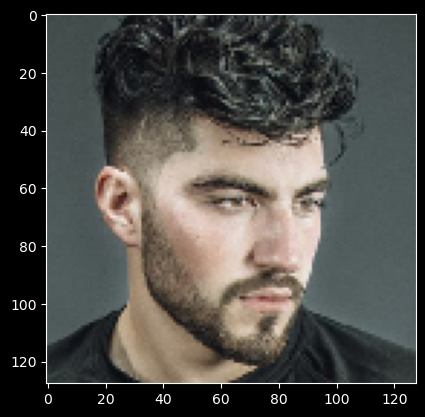

In [24]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img(
    r"C:\Users\GCE PMNA\Downloads\archive (17)\training_real\real_00008.jpg",
    target_size=(128, 128)
)

img_array = np.array(img)

# 🔥 IMPORTANT STEP (Normalize)
img_array = img_array / 255.0

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)

print(img_array.shape)

prediction = model.predict(img_array)

print("Raw prediction:", prediction)
plt.imshow(img)
# If you used sigmoid activation (Binary classification)
if prediction[0][0] > 0.5:
    print("Predicted class: Real")
else:
    print("Predicted class: Fake")